/tmp/ipykernel_2745/788806676.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-52782.523438,0.373745,-71.576535,1036.941577,17845,20.336182
2,-7.717525,0.461364,-0.430168,0.938786,17537,19.985185
3,-4.678460,0.510548,-0.160835,0.563006,17063,19.445014
4,-2.524508,0.558597,-0.011601,0.365418,17537,19.985185
5,-1.506999,0.853179,0.148110,0.238195,17768,20.248433


Returns Analysis


,1D,5D,10D
Ann. alpha,0.146,0.099,0.082
beta,-0.007,0.015,0.038
Mean Period Wise Return Top Quantile (bps),8.303,4.760,4.873
Mean Period Wise Return Bottom Quantile (bps),-8.295,-9.016,-7.932
Mean Period Wise Spread (bps),16.598,13.759,12.919


<Figure size 640x480 with 0 Axes>

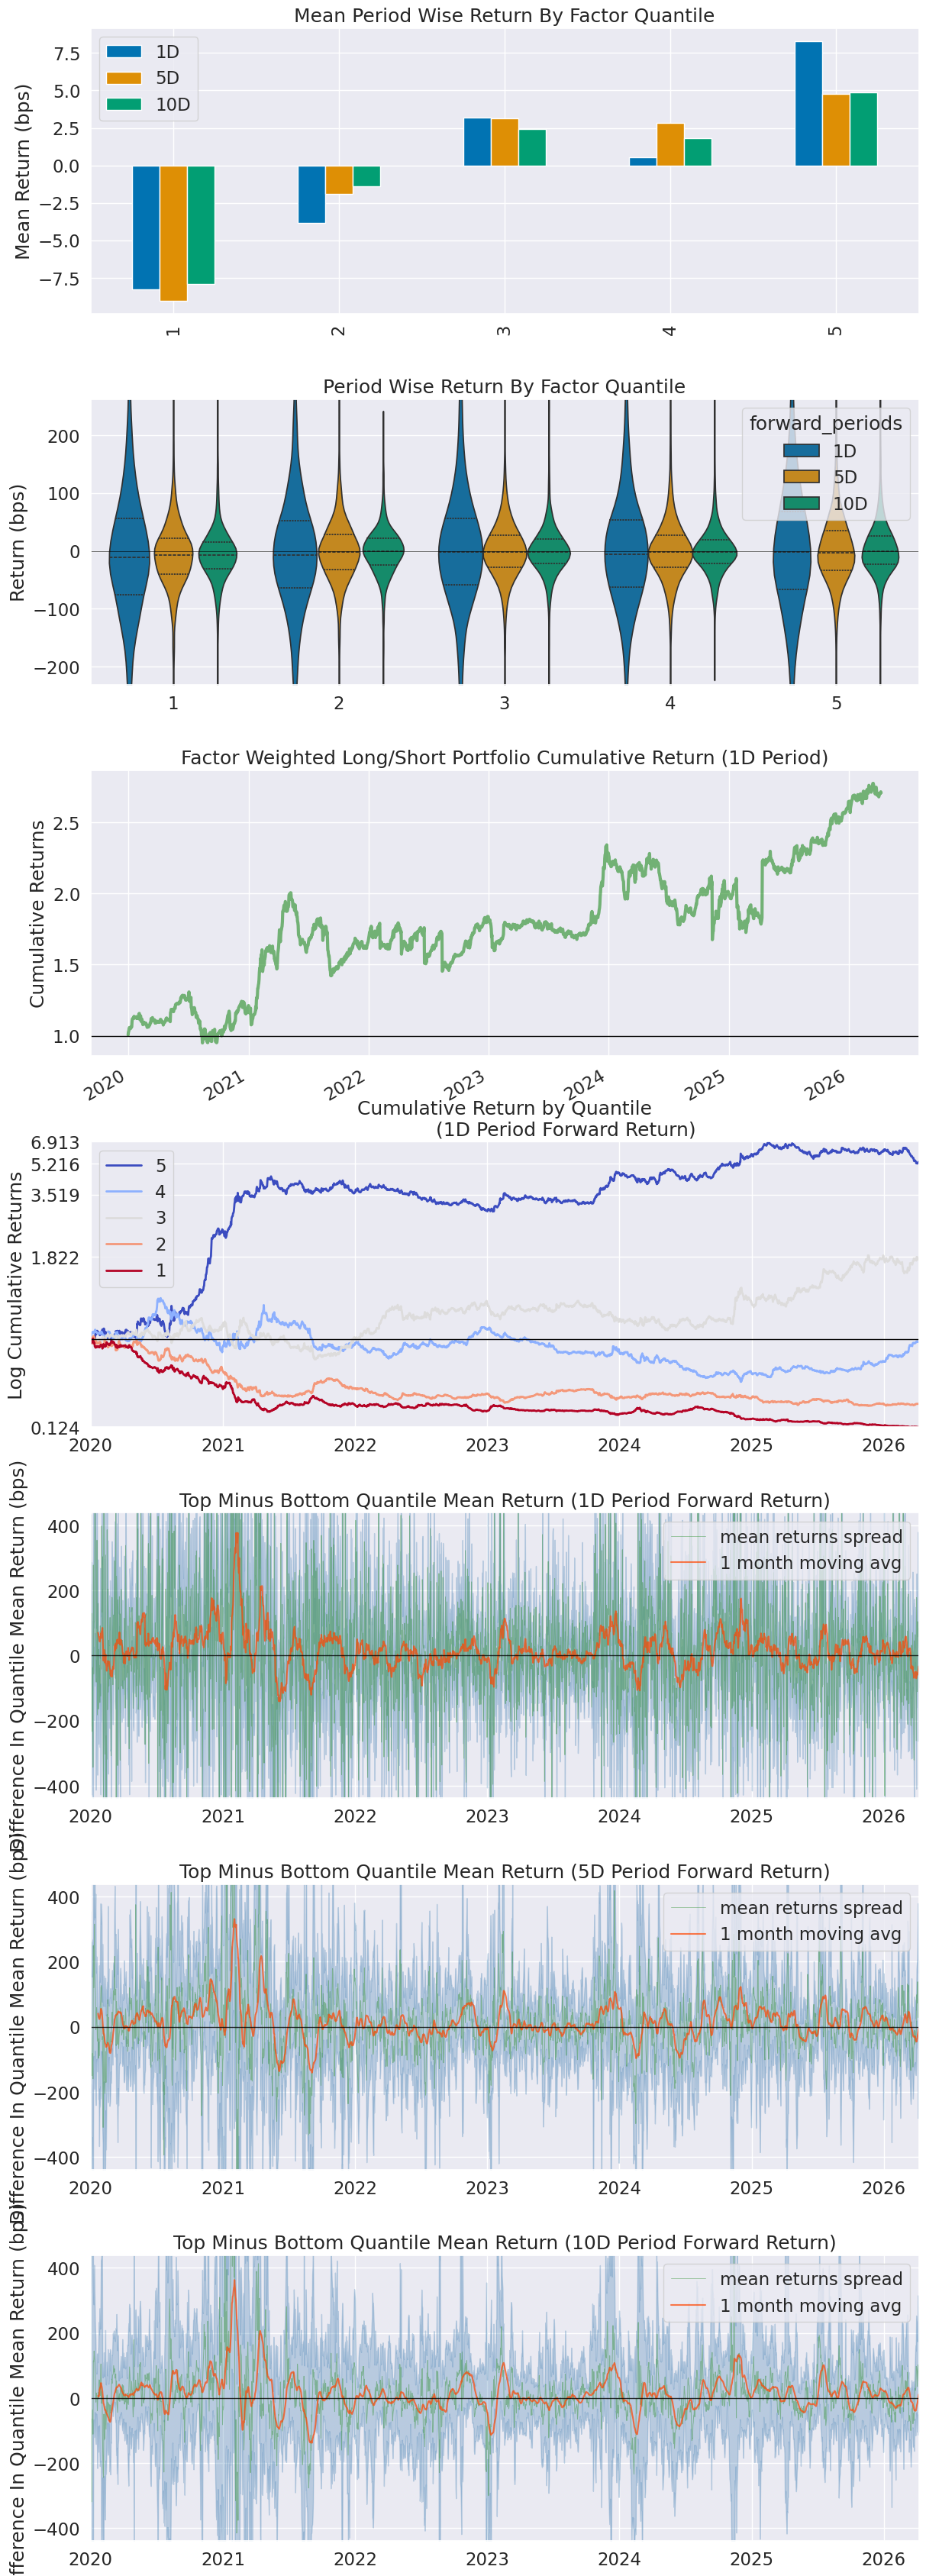

Information Analysis


,1D,5D,10D
IC Mean,0.004,0.011,0.013
IC Std.,0.207,0.206,0.211
Risk-Adjusted IC,0.021,0.052,0.060
t-stat(IC),1.009,2.465,2.871
p-value(IC),0.313,0.014,0.004
IC Skew,-0.048,-0.015,0.041
IC Kurtosis,-0.224,-0.315,-0.389


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


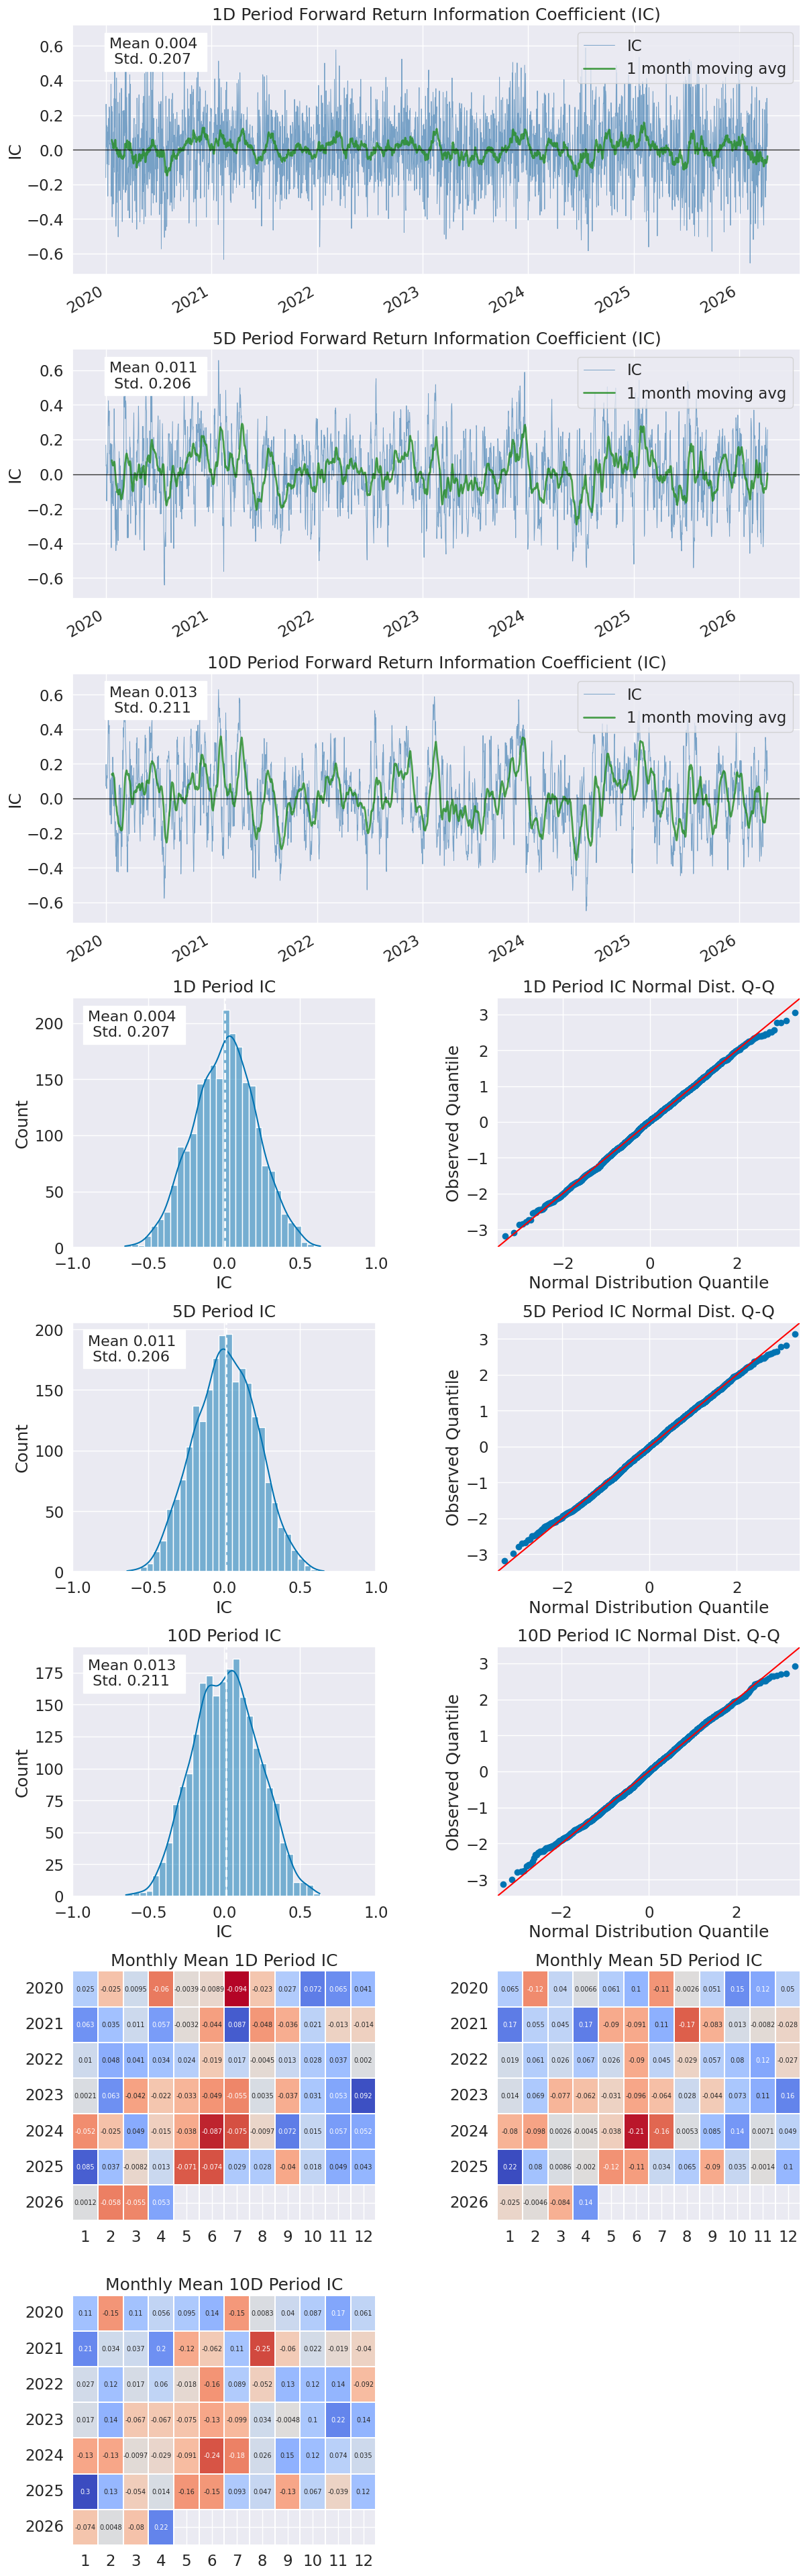

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.085,0.183,0.244
Quantile 2 Mean Turnover,0.186,0.345,0.425
Quantile 3 Mean Turnover,0.241,0.434,0.521
Quantile 4 Mean Turnover,0.238,0.429,0.505
Quantile 5 Mean Turnover,0.132,0.284,0.359


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.978,0.916,0.883


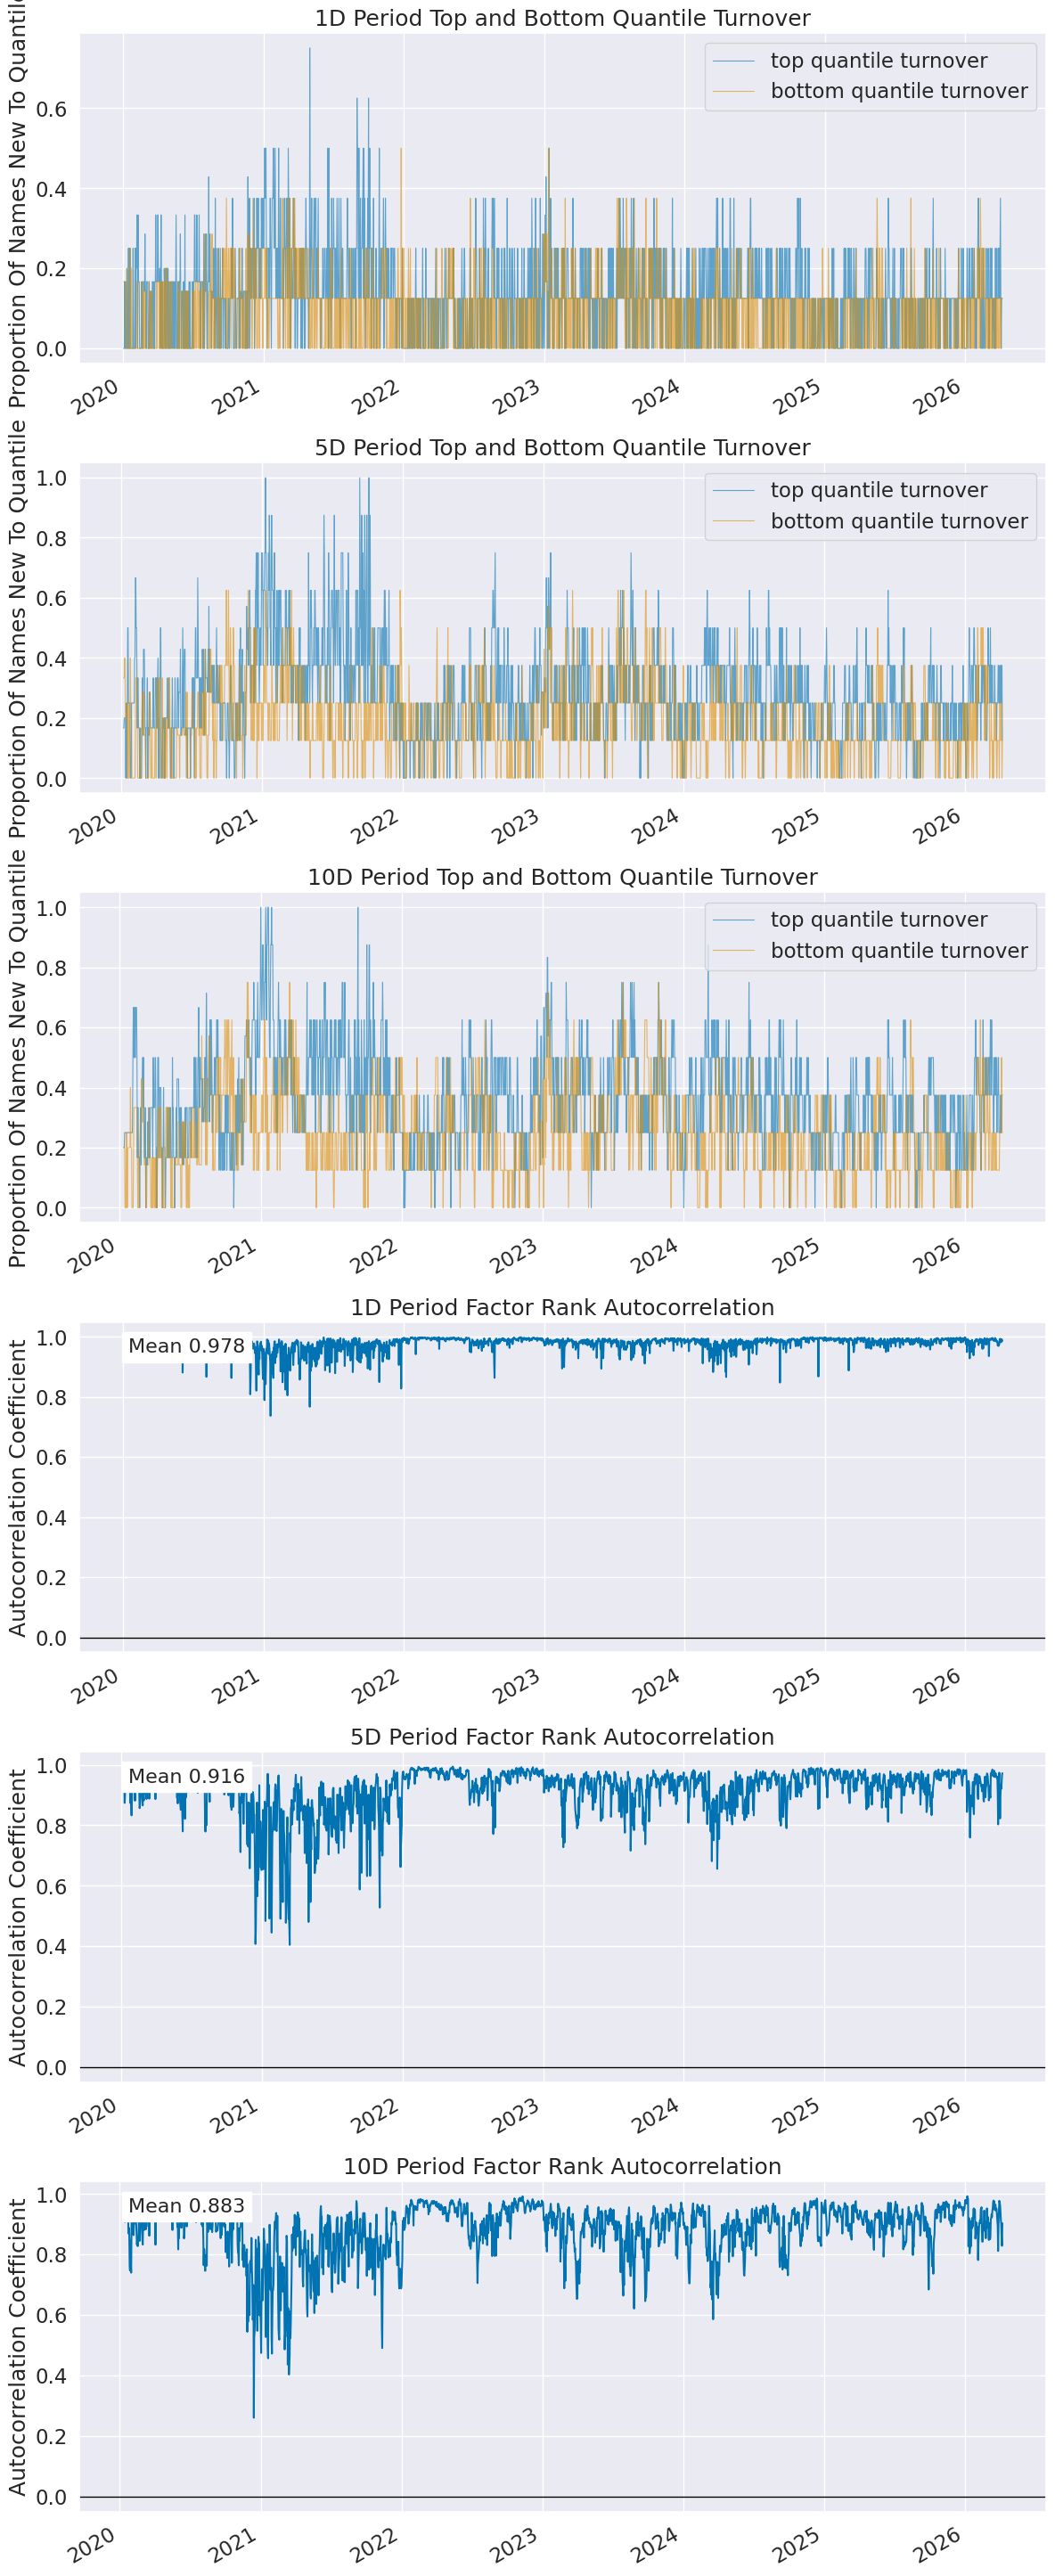

In [1]:
# AUTO-GENERATED by scripts/generate_factor_notebooks.py from
# scripts/factors_catalog.py -- do not edit by hand. Re-run the
# generator (or the "Generate Notebooks" workflow) to refresh.
import sys
from pathlib import Path

_repo_root = Path.cwd()
while not (_repo_root / "analysis").is_dir() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Mean Reversion -- portfolio mean_reversion.40
portfolio = "mean_reversion"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Restrict the analysis to the *dynamic* point-in-time universe rather than
# every ticker that was ever tradeable. get_historical_universe returns a
# boolean membership matrix (dates x tickers); masking the raw factor with it
# drops each asset on the days it was out of universe, so AlphaLens scores
# the factor on the universe we actually trade.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)